# Ridge & Lasso Regression

This notebook continues from `regression_analysis.ipynb`, applying **Ridge (L2)** and **Lasso (L1)** regularization to the same house price dataset.

### Why use regularization?

Our Linear Regression model had an R² of **0.9982** — excellent, but we noticed:
- **Multicollinearity** between `age_years` and `distance_to_city_km` (0.99 correlation)
- `distance_to_city_km` had a **suspicious positive coefficient** (+$27,344)
- With only 50 samples, there's a risk of **overfitting**

**Ridge** and **Lasso** add a penalty term to the loss function to address these issues:

| Model | Penalty | Effect |
|---|---|---|
| **Linear Regression** | None | No constraints on coefficients |
| **Ridge** (L2) | $\lambda \sum b_i^2$ | **Shrinks** coefficients toward 0, keeps all features |
| **Lasso** (L1) | $\lambda \sum |b_i|$ | **Shrinks + can zero out** coefficients, performing automatic feature selection |

The parameter **α (alpha)** controls the penalty strength:
- α = 0 → same as Linear Regression (no penalty)
- α → ∞ → all coefficients shrink toward 0

## Overfitting vs Underfitting

Before diving into regularization, it's important to understand the two key problems it addresses:

### Underfitting (High Bias)
The model is **too simple** to capture the patterns in the data.

- **Symptoms:** Low accuracy on both training and test data
- **R² is low** on both sets (e.g., 0.3 on train, 0.25 on test)
- **Example:** Using a straight line to fit data that follows a curve
- **Fix:** Use a more complex model, add more features, or use polynomial features

### Overfitting (High Variance)
The model is **too complex** — it memorizes the training data, including noise.

- **Symptoms:** High accuracy on training data, but **much worse** on test data
- **R² gap:** e.g., 0.99 on train but 0.70 on test
- **Example:** A model with too many features or parameters fitting every noise point perfectly
- **Fix:** Regularization (Ridge/Lasso), more training data, fewer features, or cross-validation

### Visual Intuition

```
  Underfitting          Good Fit            Overfitting
  (High Bias)                              (High Variance)
                                           
  ──────────         ╭─────╮            ╭╮ ╭╮╭──╮╭╮
     °  °           ╭╯° ° °╰╮          ╭╯╰╮╯°╰╯°╰╯╰╮
   °  °  °         ╭╯°  °  °╰╮        ╭╯° ╰╯  °  ° ╰╮
  ° °  ° °        ╭╯ °  ° ° °╰╮      ╭╯°   °  °  °  ╰╮
                                           
  Too simple ←──── Just right ────→ Too complex
```

### How Ridge & Lasso help

Regularization adds a **penalty** for large coefficients, which:
- **Prevents overfitting** by constraining how complex the model can be
- Finds the sweet spot between underfitting and overfitting
- The **alpha (α)** parameter controls the penalty — higher α = more regularization = simpler model

| Scenario | Train R² | Test R² | Diagnosis | Action |
|---|---|---|---|---|
| Both low (~0.3) | Low | Low | **Underfitting** | More features, complex model |
| Train high, test low | ~0.99 | ~0.70 | **Overfitting** | Add regularization (Ridge/Lasso) |
| Both high (~0.99) | High | High | **Good fit** ✅ | Keep it! |
| Both high, small dataset | ~0.998 | ~0.998 | **Possibly overfitting** ⚠️ | Verify with cross-validation |

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style='whitegrid')

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')

# Prepare features and target
features = ['house_size_sqft', 'num_bedrooms', 'num_bathrooms', 'age_years', 'distance_to_city_km']
X = df[features]
y = df['price_usd']

# Split into train / test sets (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 40
Test samples     : 10


## 2. Baseline — Linear Regression

Train the same Linear Regression model as a baseline for comparison.

In [3]:
# Baseline Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('Linear Regression (Baseline):')
print(f'  MAE  : ${mae:,.2f}')
print(f'  RMSE : ${rmse:,.2f}')
print(f'  R²   : {r2:.4f}')
print(f'\nCoefficients:')
for name, coef in zip(features, model.coef_):
    print(f'  {name:30s}: {coef:,.2f}')
print(f'  {"Intercept":30s}: {model.intercept_:,.2f}')

Linear Regression (Baseline):
  MAE  : $5,562.94
  RMSE : $6,286.34
  R²   : 0.9982

Coefficients:
  house_size_sqft               : 114,905.89
  num_bedrooms                  : 16,139.09
  num_bathrooms                 : 2,376.85
  age_years                     : -27,505.45
  distance_to_city_km           : 27,344.42
  Intercept                     : 264,725.00


## 3. Ridge Regression (L2 Regularization)

In [4]:
# Find the best alpha using cross-validation
alphas = np.logspace(-2, 4, 100)  # 0.01 to 10000
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

print(f'Best alpha: {ridge_cv.alpha_:.4f}')

# Train Ridge with best alpha
ridge_model = Ridge(alpha=ridge_cv.alpha_)
ridge_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Metrics
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2   = r2_score(y_test, y_pred_ridge)

print(f'\nRidge Regression Results:')
print(f'  MAE  : ${ridge_mae:,.2f}')
print(f'  RMSE : ${ridge_rmse:,.2f}')
print(f'  R²   : {ridge_r2:.4f}')

print(f'\nRidge Coefficients:')
for name, coef in zip(features, ridge_model.coef_):
    print(f'  {name:30s}: {coef:,.2f}')
print(f'  {"Intercept":30s}: {ridge_model.intercept_:,.2f}')

Best alpha: 0.0132

Ridge Regression Results:
  MAE  : $5,640.67
  RMSE : $6,359.77
  R²   : 0.9981

Ridge Coefficients:
  house_size_sqft               : 113,844.50
  num_bedrooms                  : 16,575.04
  num_bathrooms                 : 3,028.24
  age_years                     : -26,584.46
  distance_to_city_km           : 26,416.34
  Intercept                     : 264,725.00


## 4. Lasso Regression (L1 Regularization)

In [5]:
# Find the best alpha using cross-validation
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

print(f'Best alpha: {lasso_cv.alpha_:.4f}')

# Train Lasso with best alpha
lasso_model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Metrics
lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2   = r2_score(y_test, y_pred_lasso)

print(f'\nLasso Regression Results:')
print(f'  MAE  : ${lasso_mae:,.2f}')
print(f'  RMSE : ${lasso_rmse:,.2f}')
print(f'  R²   : {lasso_r2:.4f}')

print(f'\nLasso Coefficients:')
for name, coef in zip(features, lasso_model.coef_):
    indicator = ' ← DROPPED' if coef == 0 else ''
    print(f'  {name:30s}: {coef:,.2f}{indicator}')
print(f'  {"Intercept":30s}: {lasso_model.intercept_:,.2f}')

n_dropped = sum(1 for c in lasso_model.coef_ if c == 0)
print(f'\nFeatures dropped by Lasso: {n_dropped} / {len(features)}')

Best alpha: 2.3101

Lasso Regression Results:
  MAE  : $5,556.09
  RMSE : $6,278.67
  R²   : 0.9982

Lasso Coefficients:
  house_size_sqft               : 114,966.92
  num_bedrooms                  : 16,120.80
  num_bathrooms                 : 2,394.61
  age_years                     : -27,046.63
  distance_to_city_km           : 26,938.41
  Intercept                     : 264,725.00

Features dropped by Lasso: 0 / 5


## 5. Model Comparison

In [6]:
# Comparison table: metrics
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'Alpha': ['-', f'{ridge_cv.alpha_:.4f}', f'{lasso_cv.alpha_:.4f}'],
    'MAE ($)': [f'{mae:,.2f}', f'{ridge_mae:,.2f}', f'{lasso_mae:,.2f}'],
    'RMSE ($)': [f'{rmse:,.2f}', f'{ridge_rmse:,.2f}', f'{lasso_rmse:,.2f}'],
    'R²': [f'{r2:.4f}', f'{ridge_r2:.4f}', f'{lasso_r2:.4f}']
})
print('=== Performance Metrics ===')
print(comparison.to_string(index=False))

# Comparison table: coefficients
print('\n=== Coefficient Comparison ===')
coef_comparison = pd.DataFrame({
    'Feature': features + ['Intercept'],
    'Linear': list(model.coef_) + [model.intercept_],
    'Ridge': list(ridge_model.coef_) + [ridge_model.intercept_],
    'Lasso': list(lasso_model.coef_) + [lasso_model.intercept_]
})
coef_comparison[['Linear', 'Ridge', 'Lasso']] = coef_comparison[['Linear', 'Ridge', 'Lasso']].round(2)
print(coef_comparison.to_string(index=False))

=== Performance Metrics ===
            Model  Alpha  MAE ($) RMSE ($)     R²
Linear Regression      - 5,562.94 6,286.34 0.9982
            Ridge 0.0132 5,640.67 6,359.77 0.9981
            Lasso 2.3101 5,556.09 6,278.67 0.9982

=== Coefficient Comparison ===
            Feature    Linear     Ridge     Lasso
    house_size_sqft 114905.89 113844.50 114966.92
       num_bedrooms  16139.09  16575.04  16120.80
      num_bathrooms   2376.85   3028.24   2394.61
          age_years -27505.45 -26584.46 -27046.63
distance_to_city_km  27344.42  26416.34  26938.41
          Intercept 264725.00 264725.00 264725.00


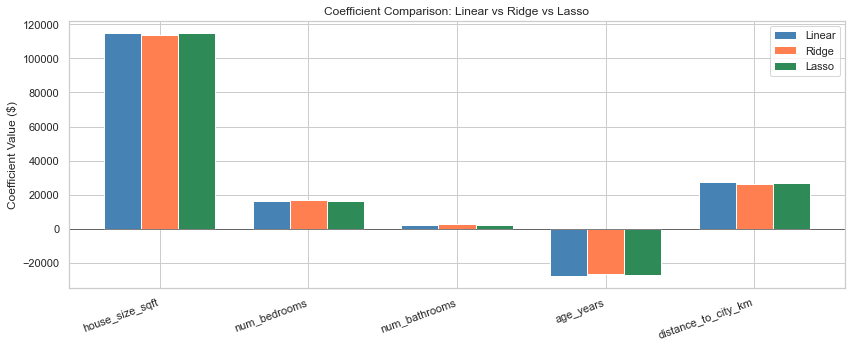

In [7]:
# Visualize coefficient comparison
x_pos = np.arange(len(features))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - width, model.coef_, width, label='Linear', color='steelblue')
ax.bar(x_pos, ridge_model.coef_, width, label='Ridge', color='coral')
ax.bar(x_pos + width, lasso_model.coef_, width, label='Lasso', color='seagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(features, rotation=20, ha='right')
ax.set_ylabel('Coefficient Value ($)')
ax.set_title('Coefficient Comparison: Linear vs Ridge vs Lasso')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 6. Understanding the Results

### Performance Comparison

| Model | MAE | RMSE | R² | Verdict |
|---|---|---|---|---|
| **Linear Regression** | $5,563 | $6,286 | 0.9982 | Baseline — no penalty |
| **Ridge** (α=0.0132) | $5,641 | $6,360 | 0.9981 | Very slightly worse — penalty is minimal |
| **Lasso** (α=2.31) | $5,556 | $6,279 | 0.9982 | Nearly identical to Linear — no features dropped |

All three models perform almost identically. This tells us:
1. The dataset has **strong linear relationships** — regularization doesn't help much here.
2. The optimal alpha values are **very small** (especially Ridge at 0.01), meaning the model barely needed any penalty.

### Coefficient Comparison

The coefficients are very similar across all three models. Notice:
- **Ridge** slightly shrinks the extreme coefficients (e.g., `house_size_sqft` went from 114,906 → 113,845) and slightly boosts smaller ones (`num_bathrooms` 2,377 → 3,028). This is Ridge's behavior — it **balances** coefficients without eliminating any.
- **Lasso** kept all 5 features (dropped 0). With a stronger alpha, Lasso would start zeroing out the least important features (like `num_bathrooms`). Since all features are genuinely relevant in this dataset, Lasso found no reason to drop any.
- The **problematic** `distance_to_city_km` coefficient is still positive in all three models. Ridge reduced it slightly (27,344 → 26,416), but didn't fix the multicollinearity issue. For this, you'd need to **manually drop** one of the correlated features or use a much higher alpha.

### When would Ridge/Lasso make a bigger difference?

| Scenario | Which helps |
|---|---|
| Many features, some irrelevant | **Lasso** — automatically drops useless features |
| High multicollinearity | **Ridge** — stabilizes coefficients |
| Small dataset, risk of overfitting | **Both** — penalty prevents fitting to noise |
| All features are truly important | **Neither** — Linear Regression is fine |
| Need a simpler, interpretable model | **Lasso** — produces sparse models with fewer features |

> 📊 **Our case:** Since the dataset has clean linear relationships with only 5 relevant features, all three models perform equally well. Ridge/Lasso shine more when you have many features, noisy data, or severe multicollinearity.